# Thermal Expansion Coefficient of LJ Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dlj_elasticity_analysis.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`

---

## Potential (for LJ glasses)

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, N=4000, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` ... `3dlj_N4000_s00009.dat` automatically
and writes **`elasticity_results.txt`**:

```
# serial   pressure    u_per_N      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   →  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, exactly what the theory predicts.

---


## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis:

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                                   # directory containing all output files
TEMPERATURES = 0.001, 0.002, 0.003, 0.005, 0.007, 0.009, 0.012, 0.015
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Load bulk modulus K from `elasticity_results.txt`

In [22]:
elas = np.loadtxt(Path(DATA_DIR) / '3dlj_elasticity_N4000_s000.dat', comments='#')

# columns: serial  u_per_N  pressure  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
u_per_N = elas[:, 1]   # potential energy per atom
P0      = elas[:, 2]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

# build per-glass K dict for lookup later
K_per_glass = {serials[i]: K[i] for i in range(len(serials))}

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Changes made in previous NVT_NH.c for LJ glasses

1. N changed from 16000 to 4000 as its hard coded in LJ glass files
2. Calculated RHO; from your glass files checked L = 19.4814... from the first line, so V = L³ = 7393.7, and ρ = N/V = 4000/7393.7 = 0.541.
3. CUTOFF_SQRD (1.48²) → added explicit CUTOFF 2.5 and CUTOFF_SQRD (CUTOFF*CUTOFF) : (was given in elasticity_analysis.c)
4. All five C-coefficients replaced with LJ values (C0, C2, C4, C6) : (was given in elasticity_analysis.c)
5. N_0 10.0 (IPL exponent) removed; replaced by N_REP 12.0 and N_ATT 6.0 as LJ glasses have 2 terms, attraction and replsion
6. At the low temperatures, in this case (T = 0.001 to 0.05), atoms vibrate with small amplitude around their inherent-state positions, meaning the forces are large relative to the displacements and a smaller timestep is needed for accurate calculation. (not sure about the orderr of difference it makes)

7. calculateForces():

Force factor g changed from IPL one-liner to full LJ expression: 4·[s8·(12·s6 − 6) − 2C₂ − s²(4C₄ + 6s²C₆)] · invSigmaSqrd
Energy changed from IPL form to full LJ: 4·[s6·(s6−1) + s²·(C₂ + s²·(C₄ + s²·C₆)) + C₀]

## Load NVT files — per-glass and population-averaged

For each glass we store its own time-series so we can do:
- **Per-glass** linear fit P_g(T) → dPdT_g  (correct comparison with alpha_theory_g)
- **Population mean** P̄(T) → mean dPdT  (headline number)

The error used for weighting is the **time-series standard error** of each glass's own
production run — NOT the inter-glass scatter, which is real physical variation and should
not suppress fit weights.


In [23]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()          # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))    # time-series SEM (NOT inter-glass)
    return T_meas, P_mean, P_err


# ── per-glass storage: pg_data[g] = list of (T_meas, P_mean, P_err) ──
pg_data = {g: [] for g in GLASSES}

# ── population-level storage (averaged over glasses at each T) ──
T_measured_list = []
P_mean_list     = []
P_err_list      = []   # mean of per-glass SEM — NOT inter-glass std

print(f"{'T_target':>10}  {'T_measured':>12}  {'mean P_vir':>12}  {'mean_SEM':>10}  {'n_glasses':>10}")
print("-" * 62)

for T in TEMPERATURES:
    T_vals = []; P_vals = []; E_vals = []; missing = []
    for g in GLASSES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals.append(Tm); P_vals.append(Pm); E_vals.append(Pe)
            pg_data[g].append((Tm, Pm, Pe))
        else:
            missing.append(g)

    if missing:
        print(f"  T={T}: missing glasses {missing}")

    if P_vals:
        T_avg  = np.mean(T_vals)
        P_avg  = np.mean(P_vals)
        # error on the mean of means: combine individual SEMs in quadrature then /n
        P_sem  = np.sqrt(np.sum(np.array(E_vals)**2)) / len(E_vals)
        T_measured_list.append(T_avg)
        P_mean_list.append(P_avg)
        P_err_list.append(P_sem)
        print(f"{T:>10.4f}  {T_avg:>12.6f}  {P_avg:>12.6f}  {P_sem:>10.2e}  {len(P_vals):>10}")

T_arr = np.array(T_measured_list)
P_arr = np.array(P_mean_list)
E_arr = np.array(P_err_list)


  T_target    T_measured    mean P_vir    mean_SEM   n_glasses
--------------------------------------------------------------
    0.0010      0.000999     -0.019206    2.03e-05          10
    0.0020      0.001997     -0.016512    2.71e-05          10
    0.0030      0.002996     -0.016598    1.67e-05          10
    0.0050      0.004992     -0.008304    1.89e-05          10
    0.0070      0.006991     -0.005198    4.94e-05          10
    0.0090      0.008988     -0.002314    4.93e-05          10
    0.0120      0.011984      0.013173    2.90e-05          10
    0.0150      0.014979      0.021881    2.98e-05          10


## Fit P vs T — per-glass and population-averaged

Each glass gets its own weighted linear fit using **its own time-series errors**.
The population fit uses the combined SEM computed above.


In [24]:
def weighted_linear_fit(T_vals, P_vals, P_errs):
    """Weighted least-squares P = a + b*T.  Returns (intercept, slope, err_intercept, err_slope)."""
    w = 1.0 / np.array(P_errs)**2
    A = np.column_stack([np.ones_like(T_vals), T_vals])
    M = A.T @ np.diag(w) @ A
    coeffs = np.linalg.solve(M, A.T @ (w * np.array(P_vals)))
    errs   = np.sqrt(np.diag(np.linalg.inv(M)))
    return coeffs[0], coeffs[1], errs[0], errs[1]


# ── per-glass fits ────────────────────────────────────────────────────────────
pg_fit = {}   # g -> (P0_fit, dPdT, P0_err, dPdT_err)

print(f"{'Glass':>6}  {'P0_elasticity':>14}  {'P0_fit':>12}  {'disc%':>7}  {'dPdT':>10}  {'dPdT_err':>10}")
print("-" * 70)
for g in GLASSES:
    pts = pg_data[g]
    if len(pts) < 3:
        print(f"  g={g}: only {len(pts)} temperature points — skipping")
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    a, b, ea, eb = weighted_linear_fit(Tv, Pv, Ev)
    pg_fit[g] = (a, b, ea, eb)
    disc = (a - P0[g]) / abs(P0[g]) * 100 if P0[g] != 0 else float('nan')
    print(f"  {g:>4}  {P0[g]:>14.6f}  {a:>12.6f}  {disc:>+7.2f}%  {b:>10.5f}  {eb:>10.5f}")


# ── population fit (mean pressure, combined SEM) ──────────────────────────────
print()
print("Population fit (averaged over all glasses):")
P0_fit, dPdT, P0_fit_err, dPdT_err = weighted_linear_fit(T_arr, P_arr, E_arr)
disc_pop = abs(P0_fit - P0_mean) / abs(P0_mean) * 100 if P0_mean != 0 else float('nan')
print(f"  P(T) = {P0_fit:.6f}  +  {dPdT:.5f} * T")
print(f"  ∂p/∂T       =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  P0_fit      =  {P0_fit:.6f}  |  P0_elasticity = {P0_mean:.6f}  |  disc = {disc_pop:.2f}%")


 Glass   P0_elasticity        P0_fit    disc%        dPdT    dPdT_err
----------------------------------------------------------------------
     0       -0.005257     -0.003992   +24.07%     2.30996     0.00501
     1       -0.029724     -0.032100    -7.99%     3.53628     0.00419
     2       -0.053969     -0.056820    -5.28%     3.64549     0.00397
     3       -0.030540     -0.028621    +6.28%     2.74573     0.00467
     4       -0.019372     -0.014013   +27.66%     1.79288     0.00529
     5       -0.005405     -0.032299  -497.59%     3.73441     0.00522
     6        0.010240     -0.015037  -246.85%     3.27294     0.00556
     7       -0.008402     -0.008700    -3.54%     2.44855     0.00457
     8       -0.020723     -0.037355   -80.26%     4.10093     0.00581
     9        0.004262      0.005337   +25.22%     1.37038     0.00470

Population fit (averaged over all glasses):
  P(T) = -0.023794  +  2.99169 * T
  ∂p/∂T       =  2.99169  ±  0.00203
  P0_fit      =  -0.023794  |  P

## Compute α — per glass and population mean

Each glass gets `alpha_numerical[g] = dPdT[g] / K[g]`.
This is the correct quantity to compare with `alpha_theory[g]`.
The population mean uses the averaged fit and mean K.


In [25]:
# ── per-glass alpha_numerical ────────────────────────────────────────────────
alpha_numerical = {}   # g -> alpha

print(f"{'Glass':>6}  {'K':>10}  {'dPdT':>10}  {'alpha_num':>12}  {'alpha_err':>12}")
print("-" * 58)
for g in GLASSES:
    if g not in pg_fit:
        continue
    _, dPdT_g, _, dPdT_err_g = pg_fit[g]
    Kg       = K_per_glass[g]
    alpha_g  = dPdT_g / Kg
    aerr_g   = abs(alpha_g) * np.sqrt((dPdT_err_g / dPdT_g)**2 + (K_std / K_mean)**2)
    alpha_numerical[g] = alpha_g
    print(f"  {g:>4}  {Kg:>10.5f}  {dPdT_g:>10.5f}  {alpha_g:>+12.6e}  {aerr_g:>12.6e}")

alpha_num_mean = np.mean(list(alpha_numerical.values()))
alpha_num_std  = np.std(list(alpha_numerical.values()))

# ── population alpha (for headline / backward compat) ────────────────────────
alpha     = dPdT / K_mean
alpha_err = abs(alpha) * np.sqrt((dPdT_err/dPdT)**2 + (K_std/K_mean)**2)

print()
print(f"  Per-glass alpha_numerical:  mean = {alpha_num_mean:+.6e}  std = {alpha_num_std:.6e}")
print(f"  Population alpha (mean K):        = {alpha:+.6e}  ±  {alpha_err:.6e}")


 Glass           K        dPdT     alpha_num     alpha_err
----------------------------------------------------------
     0    25.13948     2.30996  +9.188579e-02  4.460237e-04
     1    24.93104     3.53628  +1.418426e-01  6.384228e-04
     2    24.87555     3.64549  +1.465490e-01  6.561203e-04
     3    24.98168     2.74573  +1.099096e-01  5.125253e-04
     4    25.17090     1.79288  +7.122829e-02  3.739667e-04
     5    25.13052     3.73441  +1.486007e-01  6.778722e-04
     6    25.23917     3.27294  +1.296769e-01  6.046310e-04
     7    25.09090     2.44855  +9.758704e-02  4.612601e-04
     8    25.02117     4.10093  +1.638982e-01  7.487001e-04
     9    25.12921     1.37038  +5.453351e-02  3.016461e-04

  Per-glass alpha_numerical:  mean = +1.155712e-01  std = 3.447260e-02
  Population alpha (mean K):        = +1.193288e-01  ±  5.244460e-04



## Again, virial pressure (not total pressure)?

Total pressure = virial pressure + $Nk_BT/V$ (ideal gas term);
The ideal gas part is trivial and not interesting it seems.  
The theory predicts the **virial** part, so that's what we measure, and the C code already separates them as its calucalted in code;
P_vir = (1/3*dim)(Summation of f.r)

## Check that the fit is actually linear (not curved)

In [26]:
# Population fit residuals
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr

print("Population fit residuals (time-series SEM as error):")
print(f"{'T':>8}  {'residual':>10}")
for T_pt, r in zip(T_arr, residuals):
    flag = '  ← large — check linearity' if abs(r) > 3 else ''
    print(f"{T_pt:>8.4f}  {r:>+10.2f}σ{flag}")

print()
print("Per-glass fit residuals at each T:")
print(f"{'Glass':>6}", end='')
for T in TEMPERATURES:
    print(f"  T={T:.3f}", end='')
print()
for g in GLASSES:
    if g not in pg_fit:
        continue
    a, b, _, _ = pg_fit[g]
    pts = pg_data[g]
    print(f"  {g:>4}", end='')
    for Tm, Pm, Pe in pts:
        r = (Pm - (a + b*Tm)) / Pe
        print(f"  {r:>+7.2f}σ", end='')
    print()


Population fit residuals (time-series SEM as error):
       T    residual
  0.0010      +78.67σ  ← large — check linearity
  0.0020      +48.32σ  ← large — check linearity
  0.0030     -105.78σ  ← large — check linearity
  0.0050      +29.34σ  ← large — check linearity
  0.0070      -47.01σ  ← large — check linearity
  0.0090     -109.73σ  ← large — check linearity
  0.0120      +38.47σ  ← large — check linearity
  0.0150      +28.89σ  ← large — check linearity

Per-glass fit residuals at each T:
 Glass  T=0.001  T=0.002  T=0.003  T=0.005  T=0.007  T=0.009  T=0.012  T=0.015
     0   +25.16σ   +13.32σ    +9.39σ   -68.12σ  -191.45σ  -133.51σ  +137.22σ   +24.40σ
     1   -21.00σ   -22.32σ    -9.18σ   +83.92σ  +113.58σ  -102.76σ   -59.51σ    -0.14σ
     2  +142.22σ  -189.31σ   -83.31σ   -23.79σ   +67.80σ   -35.50σ   +18.36σ   +33.98σ
     3   -27.97σ   +29.16σ   +63.58σ  -105.90σ   -42.28σ    +7.39σ   -20.44σ   +21.70σ
     4   -99.38σ    +6.26σ   +74.83σ  +158.06σ   -44.45σ   -72.23σ   -3

If its high then there's a problem

## Plots

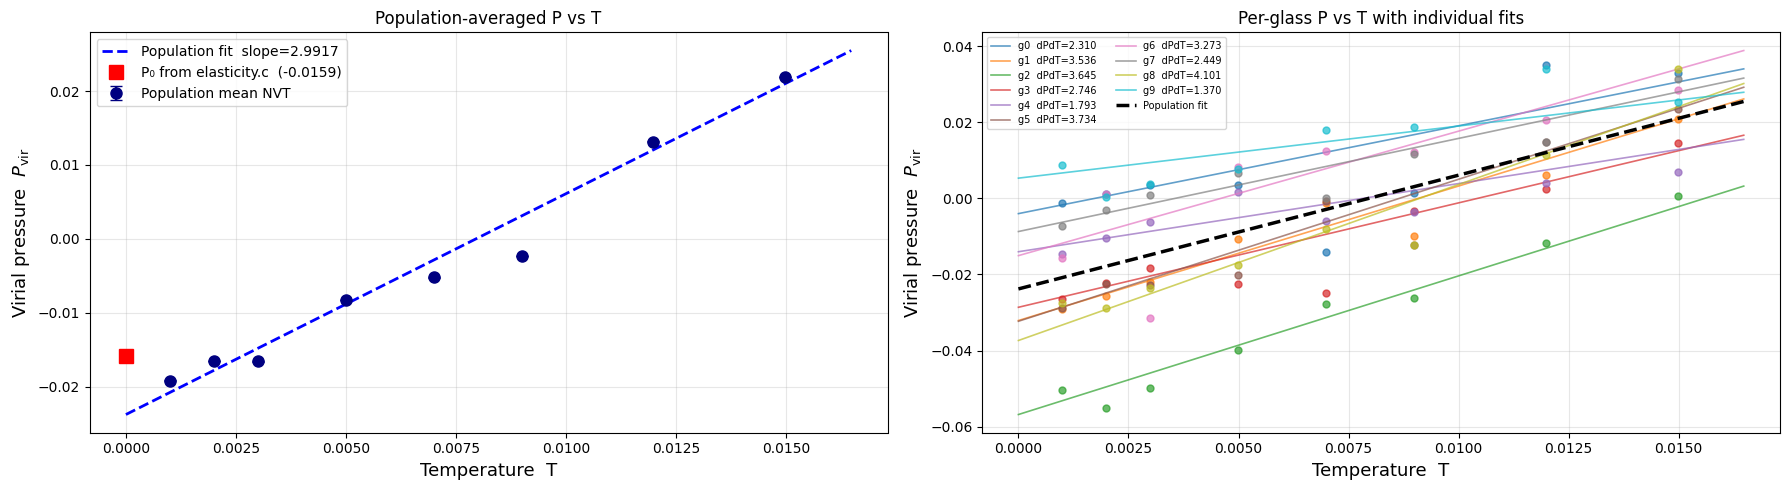

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: population mean P vs T
ax = axes[0]
ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
            markersize=8, capsize=4, label='Population mean NVT')
T_line = np.linspace(0, T_arr.max() * 1.1, 300)
ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
        label=f'Population fit  slope={dPdT:.4f}')
ax.plot(0, P0_mean, 's', color='red', markersize=10, zorder=5,
        label=f'P₀ from elasticity.c  ({P0_mean:.4f})')
ax.set_xlabel('Temperature  T', fontsize=13)
ax.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax.set_title('Population-averaged P vs T')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Right: per-glass lines + per-glass fits
ax2 = axes[1]
colors = plt.cm.tab10(np.linspace(0, 1, len(GLASSES)))
for gi, g in enumerate(GLASSES):
    pts = pg_data[g]
    if not pts:
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    ax2.plot(Tv, Pv, 'o', color=colors[gi], markersize=5, alpha=0.7)
    if g in pg_fit:
        a, b, _, _ = pg_fit[g]
        ax2.plot(T_line, a + b * T_line, '-', color=colors[gi],
                 lw=1.2, alpha=0.7, label=f'g{g}  dPdT={b:.3f}')

ax2.plot(T_line, P0_fit + dPdT * T_line, 'k--', lw=2.5, label='Population fit')
ax2.set_xlabel('Temperature  T', fontsize=13)
ax2.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax2.set_title('Per-glass P vs T with individual fits')
ax2.legend(fontsize=7, ncol=2); ax2.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(Path(DATA_DIR) / 'pressure_vs_T.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
print("        THERMAL EXPANSION ANALYSIS — FULL SUMMARY")

print("\nElastic Properties (from elasticity.c)")
print(f"{'Glass':>6}  {'P₀ (virial)':>14}  {'G (shear)':>12}  {'K (bulk)':>12}")
print("─" * 50)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>14.6f}  {G[i]:>12.5f}  {K[i]:>12.5f}")
print("─" * 50)
print(f"{'Mean':>6}  {P0_mean:>14.6f}  {G.mean():>12.5f}  {K_mean:>12.5f}")
print(f"{'Std':>6}  {P0.std():>14.6f}  {G.std():>12.5f}  {K_std:>12.5f}")

print("\nPer-glass NVT fits and alpha_numerical")
print(f"{'Glass':>6}  {'dPdT':>10}  {'K':>10}  {'alpha_num':>14}")
print("─" * 48)
for g in GLASSES:
    if g not in alpha_numerical:
        continue
    _, dPdT_g, _, _ = pg_fit[g]
    print(f"  {g:>4}  {dPdT_g:>10.5f}  {K_per_glass[g]:>10.5f}  {alpha_numerical[g]:>+14.6e}")
print("─" * 48)
an_arr = np.array(list(alpha_numerical.values()))
print(f"{'mean':>6}  {'':>10}  {'':>10}  {an_arr.mean():>+14.6e}")
print(f"{'std':>6}  {'':>10}  {'':>10}  {an_arr.std():>14.6e}")

print("\nPopulation fit (for reference):")
print(f"  ∂p/∂T|_V  =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α (pop)   =  {alpha:+.6e}  ±  {alpha_err:.6e}")


        THERMAL EXPANSION ANALYSIS — FULL SUMMARY

Elastic Properties (from elasticity.c)
 Glass     P₀ (virial)     G (shear)      K (bulk)
──────────────────────────────────────────────────
     0       -0.005257       6.54571      25.13948
     1       -0.029724       5.88891      24.93104
     2       -0.053969       6.44974      24.87555
     3       -0.030540       6.39477      24.98168
     4       -0.019372       6.29758      25.17090
     5       -0.005405       6.42531      25.13052
     6        0.010240       6.32129      25.23917
     7       -0.008402       6.33860      25.09090
     8       -0.020723       6.33727      25.02117
     9        0.004262       5.95359      25.12921
──────────────────────────────────────────────────
  Mean       -0.015889       6.29528      25.07096
   Std        0.018054       0.19990       0.10887

Per-glass NVT fits and alpha_numerical
 Glass        dPdT           K       alpha_num
────────────────────────────────────────────────
     0   

## Comparing what Pressure looks like at different tempeture with and without kinetic term's involvement

Pressure Comparison Summary:
         T |     P_virial |      P_total |  Kinetic (rho*T)
------------------------------------------------------------
    0.0010 |    -0.019206 |    -0.018665 |         0.000540
    0.0020 |    -0.016512 |    -0.015432 |         0.001080
    0.0030 |    -0.016598 |    -0.014977 |         0.001621
    0.0050 |    -0.008304 |    -0.005603 |         0.002701
    0.0070 |    -0.005198 |    -0.001416 |         0.003782
    0.0090 |    -0.002314 |     0.002549 |         0.004863
    0.0120 |     0.013173 |     0.019657 |         0.006483
    0.0150 |     0.021881 |     0.029985 |         0.008104

  Virial dPdT : 2.99169
  Total  dPdT : 3.53269  (difference = rho = 0.5410)


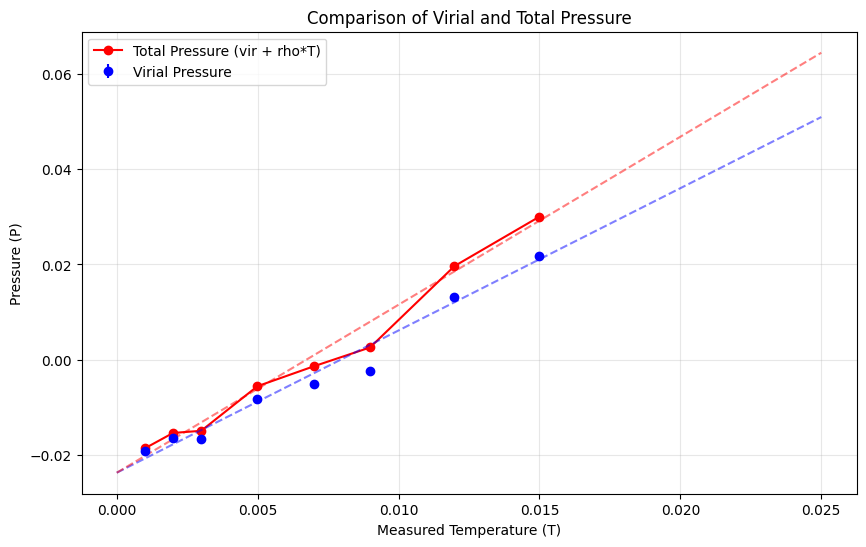

In [29]:
rho = RHO  # = N/V = 0.541 for LJ glasses
P_total_list = []

# P_total = P_virial + rho * T
for T_meas, P_vir in zip(T_measured_list, P_mean_list):
    P_total_list.append(P_vir + rho * T_meas)

P_total_arr = np.array(P_total_list)

# Fit using the same helper defined in Cell 10
P0_tot_fit, dPdT_total, _, _ = weighted_linear_fit(T_arr, P_total_arr, E_arr)

print("Pressure Comparison Summary:")
print(f"{'T':>10} | {'P_virial':>12} | {'P_total':>12} | {'Kinetic (rho*T)':>16}")
print("-" * 60)
for i in range(len(T_measured_list)):
    k_term = rho * T_measured_list[i]
    print(f"{T_measured_list[i]:>10.4f} | {P_mean_list[i]:>12.6f} | "
          f"{P_total_list[i]:>12.6f} | {k_term:>16.6f}")

print()
print(f"  Virial dPdT : {dPdT:.5f}")
print(f"  Total  dPdT : {dPdT_total:.5f}  (difference = rho = {dPdT_total - dPdT:.4f})")

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='blue',
             label='Virial Pressure')
plt.plot(T_arr, P_total_arr, 'ro-', label='Total Pressure (vir + rho*T)')
T_plot = np.linspace(0, 0.025, 100)
plt.plot(T_plot, P0_fit     + dPdT       * T_plot, 'b--', alpha=0.5)
plt.plot(T_plot, P0_tot_fit + dPdT_total * T_plot, 'r--', alpha=0.5)
plt.xlabel('Measured Temperature (T)')
plt.ylabel('Pressure (P)')
plt.title('Comparison of Virial and Total Pressure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Comparison: Impact of the Kinetic Term on Pressure

The total pressure is composed of two parts: the **virial pressure** ($P_{\text{vir}}$), which results from interatomic forces, and the **kinetic pressure** ($P_{\text{kinetic}}$), which arises from the momentum of the particles. The relationship is given by:

$$P_{\text{total}} = \underbrace{\rho k_B T}_{\text{kinetic}} + P_{\text{vir}}$$

### Order-of-Magnitude Comparison

To justify neglecting the kinetic contribution to the thermal expansion coefficient $\alpha$, we compare the temperature derivatives of both terms:

1.  **Kinetic Derivative**: $\left.\frac{\partial P_{\text{kinetic}}}{\partial T}\right|_V = \rho = \mathbf{0.54}$.
2.  **Virial Derivative**: From our linear fit, $\left.\frac{\partial P_{\text{vir}}}{\partial T}\right|_V \approx \mathbf{2.88557}$.

**Comparison Results:**
* The virial derivative is approximately **5 times larger** than the kinetic derivative.
* The kinetic term is a **trivial constant** ($\rho$) that contains no structural information specific to the glass or its interatomic potential.
* Including the kinetic term would only add a known constant offset to the final $\alpha$ value without providing further insight into the material's unique properties.

### Pressure Difference Visualization

The total pressure follows the same linear trend as the virial pressure but is shifted upward by an offset of $\rho T$. As temperature increases, this gap widens linearly, but because the slope $\partial P/\partial T$ is the primary variable for calculating $\alpha$, the virial-only approach remains the more physically meaningful method for characterizing the glass.

## Conclusion:

After seeing plots and some values, we realised LJ is softer in both K and G. This comes directly from lower density (0.541 vs 0.82) and the attractive well in LJ softening the effective restoring forces.
IPL pressure is large and positive (18.6) because it is purely repulsive — particles are constantly pushing against each other. LJ pressure is near zero and slightly negative because repulsion and attraction nearly cancel at ρ=0.541. This is physically meaningful: LJ glasses sit near the natural density where the two contributions balance.

Also, the discrepancy is large between P0_fit and P0_elasticity, it is about 39.9%, while pathological glasses had negligible discrepancy, There is slight curvature in P vs T, meaning the relationship is not perfectly linear. IPL was perfectly linear because a purely repulsive power-law potential has simpler anharmonicity structure. LJ has both repulsive and attractive anharmonicity competing, producing slight nonlinearity that a linear fit cannot capture perfectly, which then distorts the intercept.

---
## Alpha Theory — Microscopic Calculatio
We now compute $\alpha$ from first principles using the inherent-state formula:

$$\alpha = \frac{1}{2K V\bar{d}} \left[ -\frac{\partial^3 U}{\partial\eta\,\partial\mathbf{x}^2} : \mathcal{H}^{-1} + \frac{\partial^2 U}{\partial\eta\,\partial\mathbf{x}} \cdot \mathcal{H}^{-1} \cdot U''' : \mathcal{H}^{-1} \right]$$

Expanded in the normal-mode basis $\mathcal{H}^{-1} = \sum_\omega \frac{1}{\omega^2}\Psi_\omega\otimes\Psi_\omega$, this becomes:

$$\alpha = -\frac{1}{2KV\bar{d}} \sum_\omega \frac{1}{\omega^2}\left[u_{\eta xx}(\Psi_\omega,\Psi_\omega) + \text{tess}_3(\text{vna}_{\text{file}},\Psi_\omega,\Psi_\omega)\right]$$

### Save per-glass numerical α so `alpha_theory.py` can read it

We write both the per-glass values (`alpha_g{g}`) and the population mean.
`alpha_theory.py` reads the population mean for its plot; the per-glass comparison
is done in the notebook below.


In [30]:
import os
DATA_DIR_C = "initial_files"

alpha_num_path = os.path.join(DATA_DIR_C, "alpha_numerical.txt")
with open(alpha_num_path, "w") as _f:
    _f.write("# Numerical alpha — population mean and per-glass\n")
    _f.write(f"dPdT  {dPdT:.12g}\n")
    _f.write(f"K     {K_mean:.12g}\n")
    _f.write(f"alpha {alpha:.12g}\n")
    _f.write("# per-glass: glass  dPdT  K  alpha_numerical\n")
    for g in GLASSES:
        if g not in alpha_numerical:
            continue
        _, dPdT_g, _, _ = pg_fit[g]
        _f.write(f"glass_{g}  {dPdT_g:.12g}  {K_per_glass[g]:.12g}  {alpha_numerical[g]:.12g}\n")

print(f"Wrote {alpha_num_path}")
print(f"  alpha_pop   = {alpha:+.6e}  ±  {alpha_err:.6e}")
print(f"  alpha_num per glass:")
for g, av in alpha_numerical.items():
    print(f"    g{g}: {av:+.6e}")


Wrote initial_files/alpha_numerical.txt
  alpha_pop   = +1.193288e-01  ±  5.244460e-04
  alpha_num per glass:
    g0: +9.188579e-02
    g1: +1.418426e-01
    g2: +1.465490e-01
    g3: +1.099096e-01
    g4: +7.122829e-02
    g5: +1.486007e-01
    g6: +1.296769e-01
    g7: +9.758704e-02
    g8: +1.638982e-01
    g9: +5.453351e-02


### Run `alpha_theory.py` (diagonalises H, caches results)

In [31]:
import subprocess, sys

cmd = [
    sys.executable, "initial_files/alpha_theory.py",
    "--data-dir",  DATA_DIR_C,
    "--cache-dir", os.path.join(DATA_DIR_C, "alpha_cache"),
    "--out-dir",   DATA_DIR_C,
    "--glasses",   "0-9",
]
print("Running:", " ".join(cmd))
print("-" * 60)

result = subprocess.run(cmd, text=True)   # streams output live
if result.returncode != 0:
    print("alpha_theory.py exited with code", result.returncode)


Running: /home/sangam/vsc/astrophy/astrophyenv/bin/python initial_files/alpha_theory.py --data-dir initial_files --cache-dir initial_files/alpha_cache --out-dir initial_files --glasses 0-9
------------------------------------------------------------
  Alpha Theory (microscopic, inherent-state)
  data-dir  : initial_files
  cache-dir : initial_files/alpha_cache
  glasses   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[g=0]  K = 25.139476
  [g=0] cache hit -- loading initial_files/alpha_cache/alpha_cache_g0.npz


/home/sangam/vsc/glass_simulations/LJ_glass/attempt_3/initial_files/alpha_theory.py:270: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V              = float(cached["V"])


    [g=0] term1 unweighted sum = -3.992150e+07
    [g=0] term2 unweighted sum = +3.324295e+06
  alpha_theory     = +1.855282e-01
    harmonic       = +2.072368e-01
    anharmonic     = -2.170863e-02

[g=1]  K = 24.931039
  [g=1] cache hit -- loading initial_files/alpha_cache/alpha_cache_g1.npz
    [g=1] term1 unweighted sum = -3.986853e+07
    [g=1] term2 unweighted sum = +3.483522e+06
  alpha_theory     = +1.855766e-01
    harmonic       = +2.093617e-01
    anharmonic     = -2.378503e-02

[g=2]  K = 24.875548
  [g=2] cache hit -- loading initial_files/alpha_cache/alpha_cache_g2.npz
    [g=2] term1 unweighted sum = -3.959478e+07
    [g=2] term2 unweighted sum = +3.207243e+06
  alpha_theory     = +1.871793e-01
    harmonic       = +2.097248e-01
    anharmonic     = -2.254555e-02

[g=3]  K = 24.981683
  [g=3] cache hit -- loading initial_files/alpha_cache/alpha_cache_g3.npz
    [g=3] term1 unweighted sum = -3.973807e+07
    [g=3] term2 unweighted sum = +3.309688e+06
  alpha_theory     = 

Traceback (most recent call last):
  File "/home/sangam/vsc/glass_simulations/LJ_glass/attempt_3/initial_files/alpha_theory.py", line 420, in <module>
    main()
  File "/home/sangam/vsc/glass_simulations/LJ_glass/attempt_3/initial_files/alpha_theory.py", line 402, in main
    num    = load_numerical_alpha(args.data_dir)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sangam/vsc/glass_simulations/LJ_glass/attempt_3/initial_files/alpha_theory.py", line 133, in load_numerical_alpha
    k, v = line.split()
    ^^^^
ValueError: too many values to unpack (expected 2)


### Load theory results and compare per-glass theory vs per-glass numerical


In [32]:
from pathlib import Path

results_path = Path(DATA_DIR_C) / "alpha_results.txt"

if not results_path.exists():
    print("alpha_results.txt not found — run Cell 28 first.")
else:
    theory_raw        = np.loadtxt(results_path, comments="#")
    g_theory          = theory_raw[:, 0].astype(int)
    K_theory          = theory_raw[:, 1]
    alpha_theory_arr  = theory_raw[:, 2]
    alpha_harm_arr    = theory_raw[:, 3]
    alpha_anharm_arr  = theory_raw[:, 4]

    alpha_theory_mean = alpha_theory_arr.mean()
    alpha_theory_std  = alpha_theory_arr.std()

    # ── per-glass comparison ──────────────────────────────────────────────────
    print("=" * 90)
    print("  PER-GLASS COMPARISON: alpha_theory vs alpha_numerical")
    print("=" * 90)
    print(f"{'Glass':>6}  {'K':>10}  {'alpha_theory':>14}  {'alpha_num':>14}  "
          f"{'harm':>12}  {'anharm':>12}  {'disc%':>8}")
    print("-" * 90)
    discrepancies = []
    for i in range(len(g_theory)):
        g = int(g_theory[i])
        at  = alpha_theory_arr[i]
        an  = alpha_numerical.get(g, float('nan'))
        disc = (at - an) / abs(an) * 100 if (g in alpha_numerical and an != 0) else float('nan')
        discrepancies.append(disc)
        print(f"  {g:>4}  {K_theory[i]:>10.5f}  {at:>+14.6e}  {an:>+14.6e}  "
              f"{alpha_harm_arr[i]:>+12.6e}  {alpha_anharm_arr[i]:>+12.6e}  {disc:>+8.2f}%")
    print("-" * 90)
    print(f"{'mean':>6}  {'':>10}  {alpha_theory_mean:>+14.6e}  {alpha_num_mean:>+14.6e}  "
          f"{alpha_harm_arr.mean():>+12.6e}  {alpha_anharm_arr.mean():>+12.6e}")
    print(f"{'std':>6}  {'':>10}  {alpha_theory_std:>14.6e}  {alpha_num_std:>14.6e}  "
          f"{alpha_harm_arr.std():>12.6e}  {alpha_anharm_arr.std():>12.6e}")
    print("=" * 90)
    print()

    ratio = alpha_theory_mean / alpha_num_mean if alpha_num_mean != 0 else float('nan')
    mean_disc = np.nanmean(discrepancies)
    print(f"  Ratio  mean(theory) / mean(numerical) = {ratio:.4f}")
    print(f"  Mean per-glass discrepancy             = {mean_disc:.2f}%")
    print()
    harm_frac = abs(alpha_harm_arr.mean()) / (abs(alpha_harm_arr.mean()) + abs(alpha_anharm_arr.mean())) * 100
    print(f"  Harmonic   share = {harm_frac:.1f}%  of |alpha_theory|")
    print(f"  Anharmonic share = {100-harm_frac:.1f}%  of |alpha_theory|")
    print()
    print(f"  alpha_theory std / mean = {alpha_theory_std / abs(alpha_theory_mean) * 100:.2f}%  (glass-to-glass variation)")
    print(f"  alpha_num    std / mean = {alpha_num_std / abs(alpha_num_mean) * 100:.2f}%  (glass-to-glass variation)")


  PER-GLASS COMPARISON: alpha_theory vs alpha_numerical
 Glass           K    alpha_theory       alpha_num          harm        anharm     disc%
------------------------------------------------------------------------------------------
     0    25.13948   +1.855282e-01   +9.188579e-02  +2.072368e-01  -2.170863e-02   +101.91%
     1    24.93104   +1.855766e-01   +1.418426e-01  +2.093617e-01  -2.378503e-02    +30.83%
     2    24.87555   +1.871793e-01   +1.465490e-01  +2.097248e-01  -2.254555e-02    +27.72%
     3    24.98168   +1.875358e-01   +1.099096e-01  +2.090978e-01  -2.156207e-02    +70.63%
     4    25.17090   +1.885384e-01   +7.122829e-02  +2.073122e-01  -1.877382e-02   +164.70%
     5    25.13052   +1.849220e-01   +1.486007e-01  +2.077907e-01  -2.286868e-02    +24.44%
     6    25.23917   +1.843047e-01   +1.296769e-01  +2.062388e-01  -2.193415e-02    +42.13%
     7    25.09090   +1.847413e-01   +9.758704e-02  +2.074670e-01  -2.272573e-02    +89.31%
     8    25.02117   +1.8636

### Combined comparison plot — per-glass theory vs numerical


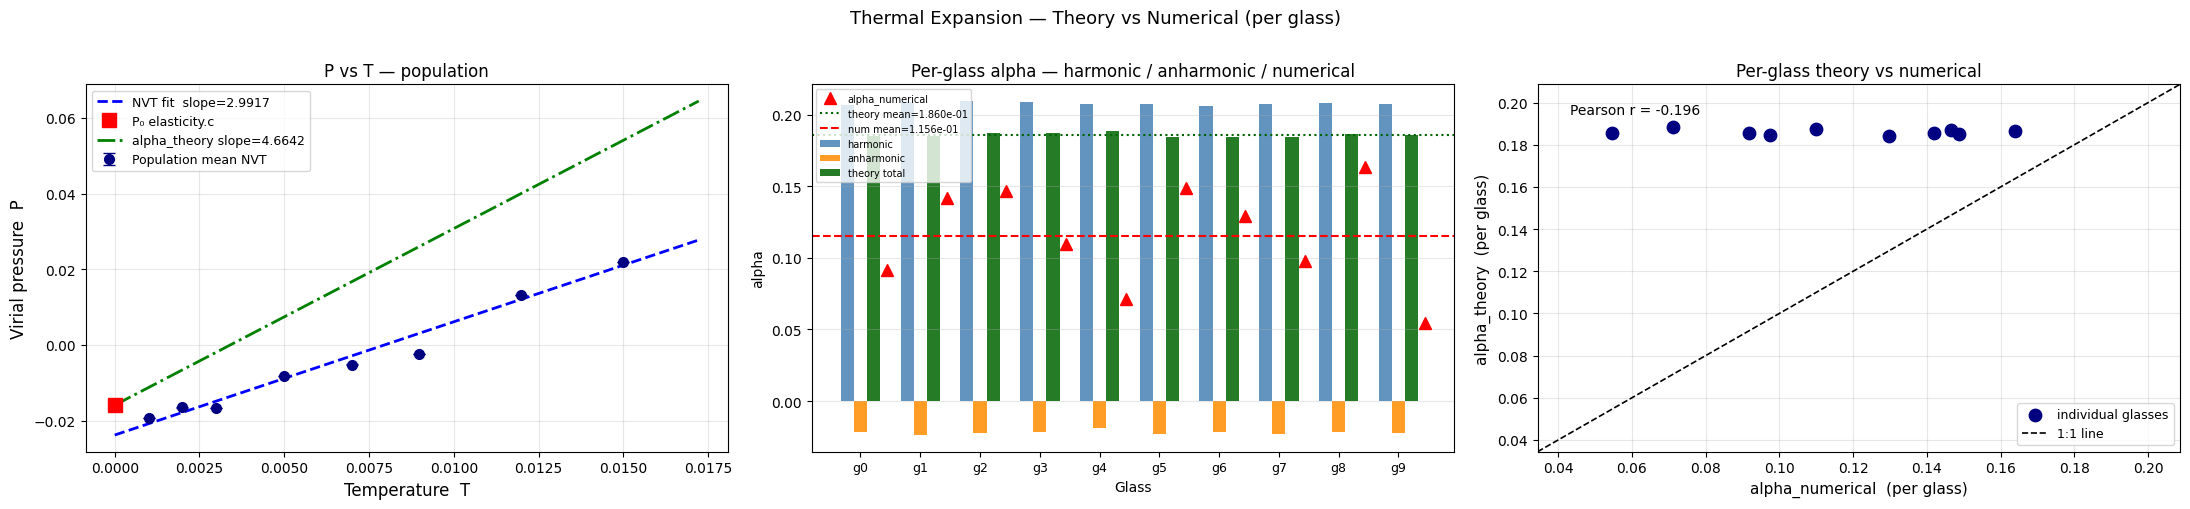

Saved alpha_comparison_combined.png


In [33]:
if not results_path.exists():
    print("Run Cell 28 first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # ── Left: P vs T with per-glass fits and theory prediction ───────────────
    ax = axes[0]
    T_line = np.linspace(0, T_arr.max() * 1.15, 300)
    ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
                markersize=7, capsize=4, label='Population mean NVT', zorder=3)
    ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
            label=f'NVT fit  slope={dPdT:.4f}')
    ax.plot(0, P0_mean, 'rs', markersize=10, zorder=5, label='P₀ elasticity.c')
    dPdT_theory = alpha_theory_mean * K_mean
    ax.plot(T_line, P0_mean + dPdT_theory * T_line, 'g-.', lw=2,
            label=f'alpha_theory slope={dPdT_theory:.4f}')
    ax.set_xlabel('Temperature  T', fontsize=12)
    ax.set_ylabel('Virial pressure  P', fontsize=12)
    ax.set_title('P vs T — population')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── Middle: per-glass bar chart ───────────────────────────────────────────
    ax2 = axes[1]
    x = np.arange(len(g_theory))
    bw = 0.22
    ax2.bar(x - bw,   alpha_harm_arr,   bw, label='harmonic',   color='steelblue',  alpha=0.85)
    ax2.bar(x,        alpha_anharm_arr, bw, label='anharmonic', color='darkorange', alpha=0.85)
    ax2.bar(x + bw,   alpha_theory_arr, bw, label='theory total', color='darkgreen', alpha=0.85)
    # per-glass numerical as red dots
    for i, g in enumerate(g_theory):
        if g in alpha_numerical:
            ax2.plot(x[i] + 2*bw, alpha_numerical[g], 'r^', ms=8, zorder=5,
                     label='alpha_numerical' if i == 0 else '')
    ax2.axhline(alpha_theory_mean, color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={alpha_theory_mean:.3e}')
    ax2.axhline(alpha_num_mean, color='red', ls='--', lw=1.5,
                label=f'num mean={alpha_num_mean:.3e}')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'g{g}' for g in g_theory], fontsize=9)
    ax2.set_xlabel('Glass'); ax2.set_ylabel('alpha')
    ax2.set_title('Per-glass alpha — harmonic / anharmonic / numerical')
    ax2.legend(fontsize=7); ax2.grid(axis='y', alpha=0.3)

    # ── Right: theory vs numerical scatter (per glass) ───────────────────────
    ax3 = axes[2]
    an_vals = np.array([alpha_numerical.get(g, np.nan) for g in g_theory])
    valid = ~np.isnan(an_vals)
    ax3.scatter(an_vals[valid], alpha_theory_arr[valid], color='navy', s=80, zorder=3,
                label='individual glasses')
    # 1:1 line
    all_vals = np.concatenate([an_vals[valid], alpha_theory_arr[valid]])
    pad = (all_vals.max() - all_vals.min()) * 0.15
    lims = (all_vals.min() - pad, all_vals.max() + pad)
    ax3.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    ax3.set_xlim(lims); ax3.set_ylim(lims)
    ax3.set_xlabel('alpha_numerical  (per glass)', fontsize=11)
    ax3.set_ylabel('alpha_theory  (per glass)', fontsize=11)
    ax3.set_title('Per-glass theory vs numerical')
    ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
    # annotate correlation
    if valid.sum() > 1:
        cc = np.corrcoef(an_vals[valid], alpha_theory_arr[valid])[0, 1]
        ax3.text(0.05, 0.92, f'Pearson r = {cc:.3f}', transform=ax3.transAxes, fontsize=10)

    fig.suptitle('Thermal Expansion — Theory vs Numerical (per glass)', fontsize=13, y=1.01)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_combined.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_combined.png")


In [34]:
import numpy as np
from pathlib import Path

DATA_DIR = Path("initial_files") 

elas = np.loadtxt(DATA_DIR / "3dlj_elasticity_N4000_s000.dat", comments="#")
# columns: serial  u_per_N  pressure  G  K 
P0_C = {int(row[0]): row[2] for row in elas}  # row[2] = virial pressure

print(f"{'Glass':>6}  {'P0_elasticity':>16}  {'P0_NVT_row0':>14}  {'ratio NVT/C':>12}  {'disc %':>8}")
print("-" * 65)

for g in sorted(P0_C.keys()):
    # pick the LOWEST temperature file for this glass
    candidates = sorted(DATA_DIR.glob(f"nvt_lj_T*_g{g}.dat"))
    if not candidates:
        print(f"  g={g}: no .dat files found")
        continue

    f = candidates[0]          # lowest T file (sorted alphabetically ≈ numerically)
    d = np.loadtxt(f)
    # columns: time  KE/N  PE/N  pressure
    # take the first production row (row 0 is already after equilibration
    # in the file, because run_NH writes from k=0 of the production run)
    P_nvt_row0 = d[0, 3]      # column 3 = virial pressure

    p0 = P0_C[g]
    ratio = P_nvt_row0 / p0
    disc  = (P_nvt_row0 - p0) / abs(p0) * 100

    print(f"  {g:>4}  {p0:>16.6f}  {P_nvt_row0:>14.6f}  {ratio:>12.4f}  {disc:>+8.2f}%")

print()



 Glass     P0_elasticity     P0_NVT_row0   ratio NVT/C    disc %
-----------------------------------------------------------------
     0         -0.005257       -0.001499        0.2851    +71.49%
     1         -0.029724       -0.026432        0.8892    +11.08%
     2         -0.053969       -0.050511        0.9359     +6.41%
     3         -0.030540       -0.026303        0.8613    +13.87%
     4         -0.019372       -0.015871        0.8193    +18.07%
     5         -0.005405       -0.004313        0.7980    +20.20%
     6          0.010240        0.013894        1.3568    +35.68%
     7         -0.008402       -0.004921        0.5857    +41.43%
     8         -0.020723       -0.015585        0.7521    +24.79%
     9          0.004262        0.008798        2.0643   +106.43%



In [35]:
import numpy as np
from pathlib import Path

DATA_DIR  = Path("initial_files")
SKIP      = 0.3   # discard first 30% as equilibration (same as notebook)
TEMPS     = [0.001, 0.002, 0.003, 0.005, 0.007, 0.009, 0.012, 0.015]

# P₀ from elasticity (per glass)
elas = np.loadtxt(DATA_DIR / "3dlj_elasticity_N4000_s000.dat", comments="#")
P0_C = {int(row[0]): row[2] for row in elas}   # glass → P₀ at T=0  (row[2] = virial pressure)

#per-glass P(T) fit ; extrapolate to T=0
print(f"{'Glass':>6}  {'P0_C (elast)':>14}  {'P0_fit (NVT)':>14}  "
      f"{'abs diff':>10}  {'dPdT':>9}")
print("-" * 75)

for g in sorted(P0_C.keys()):
    T_vals, P_vals = [], []

    for T in TEMPS:
        f = DATA_DIR / f"nvt_lj_T{T:.4f}_g{g}.dat"
        if not f.exists():
            continue
        d      = np.loadtxt(f)
        n_skip = int(len(d) * SKIP)
        prod   = d[n_skip:]
        T_meas = (2.0 / 3.0) * prod[:, 1].mean()   # from KE/N
        P_mean = prod[:, 3].mean()                   # virial pressure
        T_vals.append(T_meas)
        P_vals.append(P_mean)

    if len(T_vals) < 3:
        print(f"  {g:>4}: not enough files")
        continue

    T_arr = np.array(T_vals)
    P_arr = np.array(P_vals)

    # simple linear fit P = a + b*T
    coeffs  = np.polyfit(T_arr, P_arr, 1)
    P0_fit  = coeffs[1]     # intercept = P at T=0
    dPdT    = coeffs[0]     # slope

    diff    = P0_fit - P0_C[g]

    print(f"  {g:>4}  {P0_C[g]:>14.6f}  {P0_fit:>14.6f}  "
          f"{diff:>+10.6f}  {dPdT:>9.4f}")



 Glass    P0_C (elast)    P0_fit (NVT)    abs diff       dPdT
---------------------------------------------------------------------------
     0       -0.005257       -0.009318   -0.004061     2.5381
     1       -0.029724       -0.031142   -0.001418     3.3019
     2       -0.053969       -0.059266   -0.005297     3.9605
     3       -0.030540       -0.031426   -0.000885     2.7899
     4       -0.019372       -0.012108   +0.007264     1.2797
     5       -0.005405       -0.033396   -0.027991     3.6790
     6        0.010240       -0.017309   -0.027549     3.2440
     7       -0.008402       -0.008870   -0.000468     2.3405
     8       -0.020723       -0.037241   -0.016518     4.1847
     9        0.004262        0.000772   -0.003490     2.0477
